# 03 · Model benchmark - can we beat "same as recent form"?

Phase 3 trains four models on **one task**, with **one chronological race split**, and wraps
every model in **95 % conformal prediction intervals**.

**The task.** At the start of lap *t*, predict

$$\text{PaceDelta\_s}(t) = \text{FuelCorrectedLapTime\_s}(t) - \text{RollingPace\_s}(t)$$

i.e. how much slower (+) or faster (−) this lap will be than the driver's recent pace on the
current tyres. Predicted lap time = `RollingPace_s` + predicted delta + fuel effect.

| Model | Family | What it can learn |
|---|---|---|
| **Naive** | baseline | nothing - always predicts 0 ("this lap = recent form") |
| **Ridge** | linear baseline | one straight-line effect per feature |
| **CatBoost** | gradient-boosted trees | non-linear effects and interactions, native NaN/categorical handling |
| **MLP** | PyTorch neural net | smooth non-linear functions of the scaled features |

In [1]:
# Run from the repo root so `import src...` works and FastF1 uses data/cache/.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.models.advanced.gbdt import fit_catboost, make_catboost
from src.models.benchmark import run_benchmark
from src.models.conformal import (
    conformal_interval, interval_metrics, mapie_split_conformal, split_conformal_quantile,
)
from src.models.dataset import MODEL_FEATURES, TARGET_COLUMN, feature_matrix, load_model_table

logging.getLogger("fastf1").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 40, "display.width", 200)

plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
COMPOUND_COLORS = {"SOFT": "#e34948", "MEDIUM": "#eda100", "HARD": "#8a8984"}
LOSS, GAIN, NEUTRAL, INK = "#e34948", "#2a78d6", "#8a8984", "#52514e"
# One fixed colour per model, used in every chart. Naive is the reference -> neutral grey.
MODEL_COLORS = {"Naive": NEUTRAL, "Ridge": "#2a78d6", "CatBoost": "#eb6834", "MLP": "#1baf7a"}
MODELS = list(MODEL_COLORS)
CONFIDENCE = 0.95

## 0 · Data and the chronological split

The modelling table is the Phase 2 feature file, restricted to dry-tyre laps, with the target
added. Races are split **by whole race in calendar order**: train -> val -> calib -> test.

**What to look for**
* Every subset is a block of consecutive rounds - no race appears twice, nothing from the
  future is in train.
* val is used **only** for early stopping, calib **only** for the conformal intervals, and
  test is touched once, at the end.

In [2]:
table = load_model_table()
result = run_benchmark(table, confidence_level=CONFIDENCE)  # ~10 s: fits all four models
split = result.split

overview = pd.DataFrame([
    {"subset": name, "races": len(races), "laps": len(getattr(split, name)),
     "rounds": f"{getattr(split, name)['RoundNumber'].min()}–{getattr(split, name)['RoundNumber'].max()}",
     "race list": ", ".join(r.removeprefix("2023_") for r in races)}
    for name, races in split.races().items()
])
print(f"{len(table):,} laps from {table['RaceId'].nunique()} races, {len(MODEL_FEATURES)} features: {MODEL_FEATURES}")
overview

18,715 laps from 22 races, 8 features: ['LapNumber', 'TyreLife', 'AirTemp', 'TrackTemp', 'TrackTempDelta_C', 'AirDensity_kgm3', 'TireDegIndex_s_per_lap', 'Compound']


,subset,races,laps,rounds,race list
0,train,12,10645,1–12,"bahrain, saudi_arabian, australian, azerbaijan..."
1,val,3,2309,13–15,"dutch, italian, singapore"
2,calib,3,2231,16–18,"japanese, qatar, united_states"
3,test,4,3530,19–22,"mexico_city, sao_paulo, las_vegas, abu_dhabi"


### 0a The target

**What to look for**
* Centred just above 0: a lap is usually a little **slower** than the average of the previous
  laps, because the tyres keep degrading.
* A narrow core (most laps within ±0.5 s) with long tails - traffic, mistakes, DRS trains.
  The Naive model predicts the dashed line for every lap.

median +0.113 s · std 0.985 s · |delta| > 4 s: 0.48% of laps


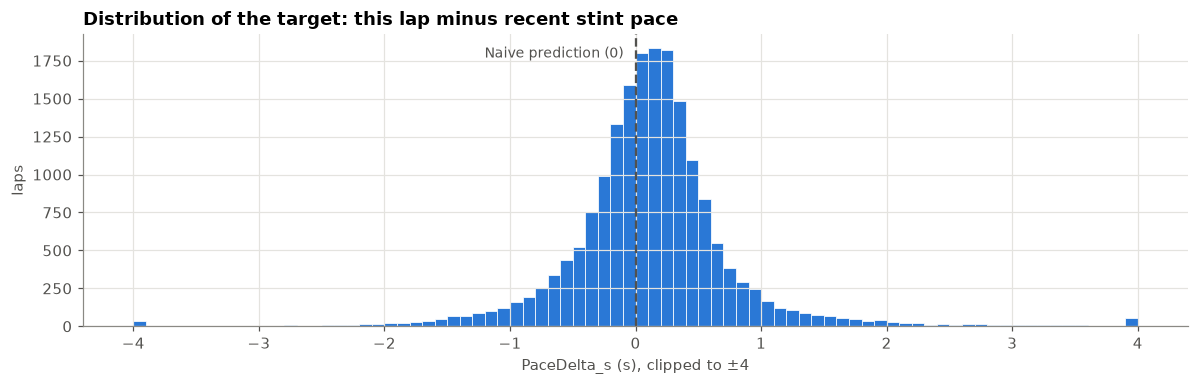

In [3]:
y = table[TARGET_COLUMN]
clip = 4
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.hist(y.clip(-clip, clip), bins=np.linspace(-clip, clip, 81), color=GAIN, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=INK, linestyle="--", linewidth=1.5)
ax.annotate("Naive prediction (0)", (0, ax.get_ylim()[1] * 0.92), xytext=(-8, 0),
            textcoords="offset points", ha="right", color=INK, fontsize=9)
ax.set_xlabel(f"{TARGET_COLUMN} (s), clipped to ±{clip}"); ax.set_ylabel("laps")
ax.set_title("Distribution of the target: this lap minus recent stint pace", loc="left")
plt.tight_layout()
print(f"median {y.median():+.3f} s · std {y.std():.3f} s · |delta| > {clip} s: {(y.abs() > clip).mean():.2%} of laps")

## 1 Point accuracy on the test races

**MAE** (mean absolute error) weighs every second of error equally; **RMSE** squares errors
first, so a few big misses dominate it. `MAE_vs_naive` is the relative improvement over the
Naive baseline (> 0 = better).

**What to look for**
* Whether **any** model clearly beats Naive. Small gains are the honest outcome when the
  features explain little of the lap-to-lap noise.
* RMSE well above MAE for every model -> heavy-tailed errors (section 6 tries a loss that is
  less sensitive to them).

In [4]:
metrics = result.metrics.set_index("model")
metrics.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "MAE_vs_naive": "{:+.1%}",
                      "q": "{:.3f}", "coverage": "{:.1%}", "mean_width": "{:.3f}"})

,MAE,RMSE,MAE_vs_naive,q,coverage,mean_width
model,,,,,,
Naive,0.456,0.657,+0.0%,1.363,94.8%,2.726
Ridge,0.439,0.643,+3.8%,1.389,95.6%,2.778
CatBoost,0.441,0.658,+3.2%,1.313,93.6%,2.626
MLP,0.474,0.691,-4.0%,1.321,94.2%,2.642


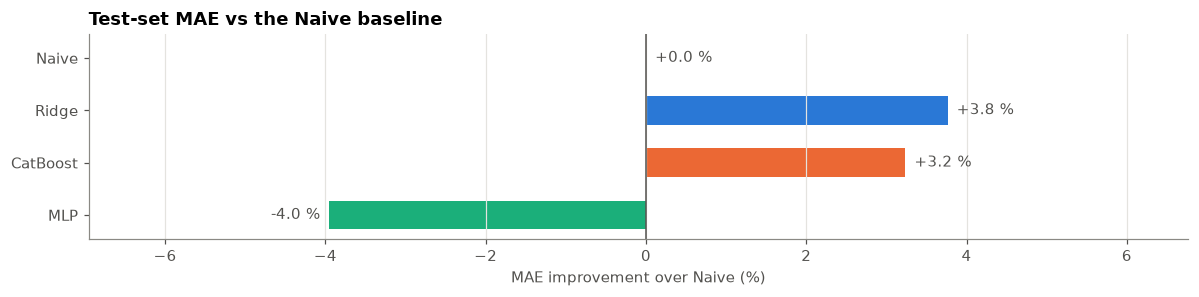

In [5]:
fig, ax = plt.subplots(figsize=(11, 2.8))
gain = metrics.loc[MODELS, "MAE_vs_naive"] * 100
ax.barh(MODELS, gain, color=[MODEL_COLORS[m] for m in MODELS], height=0.55)
ax.axvline(0, color=INK, linewidth=1)
for i, v in enumerate(gain):
    ax.annotate(f"{v:+.1f} %", (v, i), xytext=(6 if v >= 0 else -6, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center", color=INK, fontsize=10)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
lo, hi = min(gain.min(), 0), max(gain.max(), 0)
ax.set_xlim(lo - 3, hi + 3)
ax.set_xlabel("MAE improvement over Naive (%)")
ax.set_title("Test-set MAE vs the Naive baseline", loc="left")
plt.tight_layout()

### 1a Per test race

**What to look for**
* Is the ranking stable across races, or does one race decide it?
* A race where **every** model is far worse than elsewhere is a race unlike the training data.

model,Naive,Ridge,CatBoost,MLP
RaceId,,,,
2023_mexico_city,0.421,0.439,0.355,0.386
2023_sao_paulo,0.372,0.355,0.373,0.477
2023_las_vegas,0.802,0.741,0.925,0.885
2023_abu_dhabi,0.362,0.334,0.301,0.314


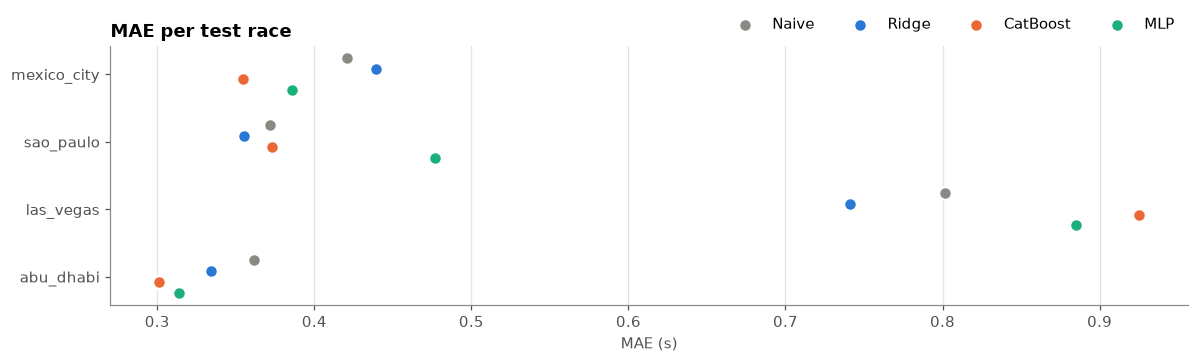

In [6]:
preds = result.predictions.copy()
preds["abs_err"] = (preds["y_true"] - preds["y_pred"]).abs()
race_order = split.races()["test"]
mae_race = preds.pivot_table(index="RaceId", columns="model", values="abs_err", aggfunc="mean").loc[race_order, MODELS]

fig, ax = plt.subplots(figsize=(11, 3.4))
labels = [r.removeprefix("2023_") for r in race_order]
offsets = np.linspace(-0.24, 0.24, len(MODELS))
for off, m in zip(offsets, MODELS):
    ax.scatter(mae_race[m], np.arange(len(labels)) + off, s=70, color=MODEL_COLORS[m],
               edgecolor="white", linewidth=1.5, label=m, zorder=3)
ax.set_yticks(range(len(labels)), labels); ax.invert_yaxis()
ax.set_xlabel("MAE (s)"); ax.grid(axis="y", visible=False)
ax.legend(ncol=4, loc="lower right", bbox_to_anchor=(1, 1.0))
ax.set_title("MAE per test race", loc="left")
plt.tight_layout()
mae_race.round(3)

## 2 What did the models learn?

### 2a Ridge coefficients and CatBoost feature importance
Ridge works on **standardised** features, so each coefficient is "seconds of PaceDelta per one
standard deviation of the feature" and the bars are directly comparable. CatBoost's importance
is the share of prediction change attributed to each feature.

**What to look for**
* `TireDegIndex_s_per_lap` should dominate both: a stint that has been degrading fast keeps
  degrading, so the next lap is slower than the recent average.
* Physically sensible signs: higher degradation index and older tyres -> slower (+).

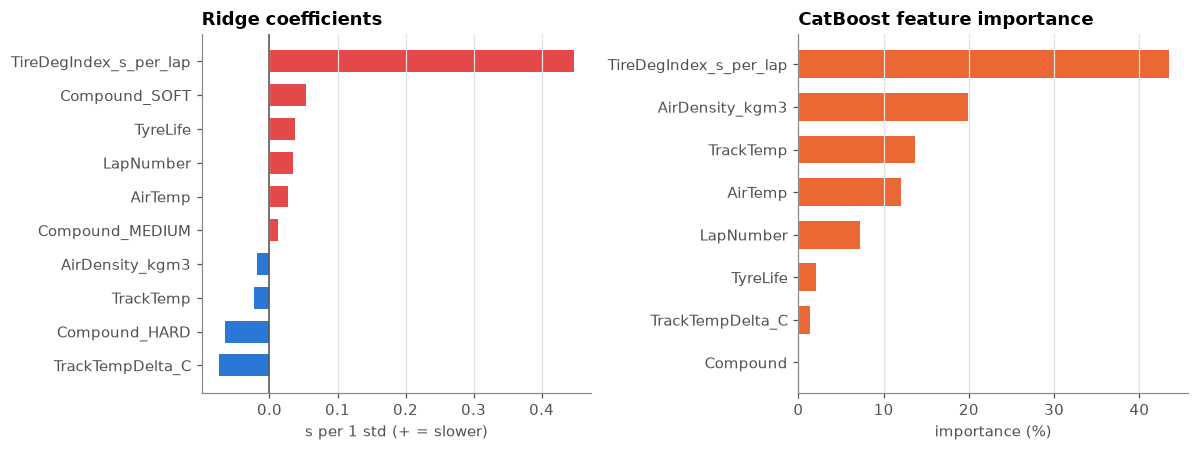

In [7]:
ridge, cat = result.models["Ridge"], result.models["CatBoost"]
coef = pd.Series(ridge["ridge"].coef_, index=ridge["preprocess"].get_feature_names_out())
coef.index = coef.index.str.replace("num__", "").str.replace("cat__", "")
coef = coef.sort_values()
importance = pd.Series(cat.get_feature_importance(), index=cat.feature_names_).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].barh(coef.index, coef, color=np.where(coef > 0, LOSS, GAIN), height=0.65)
axes[0].axvline(0, color=INK, linewidth=1)
axes[0].set_xlabel("s per 1 std (+ = slower)"); axes[0].set_title("Ridge coefficients", loc="left")
axes[1].barh(importance.index, importance, color=MODEL_COLORS["CatBoost"], height=0.65)
axes[1].set_xlabel("importance (%)"); axes[1].set_title("CatBoost feature importance", loc="left")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()

### 2b How each model uses the dominant feature (partial dependence)
Set **every** test lap's `TireDegIndex_s_per_lap` to the same value, predict, average - that
isolates what each model learned about recent degradation, all other features held as they are.

Physics gives a reference: lap *t* is on average **3 laps older** than the mean of the previous
5 laps that `RollingPace_s` averages, so with a true degradation of *d* s/lap the expected delta
is ≈ 3·*d* (dashed line).

**What to look for**
* All curves rise: a stint that has been degrading predicts a slower next lap.
* Ridge is a straight line, CatBoost a staircase (trees split on thresholds), the MLP a smooth curve.
* CatBoost goes **flat for negative values**: a stint that briefly "got faster" is mostly noise
  (or track evolution) and doesn't continue, so the trees learn to ignore it. Ridge can't - it must
  extend one straight line in both directions.
* Every curve is much **flatter** than the physics line. `TireDegIndex` is a noisy *estimate*
  from only 5 laps, and regressing on a noisy input shrinks its slope towards 0
  (*regression dilution* / attenuation bias) - the models rightly trust it only partially.
* CatBoost gives `Compound` 0 % importance: once recent degradation is known, the compound
  name adds nothing.

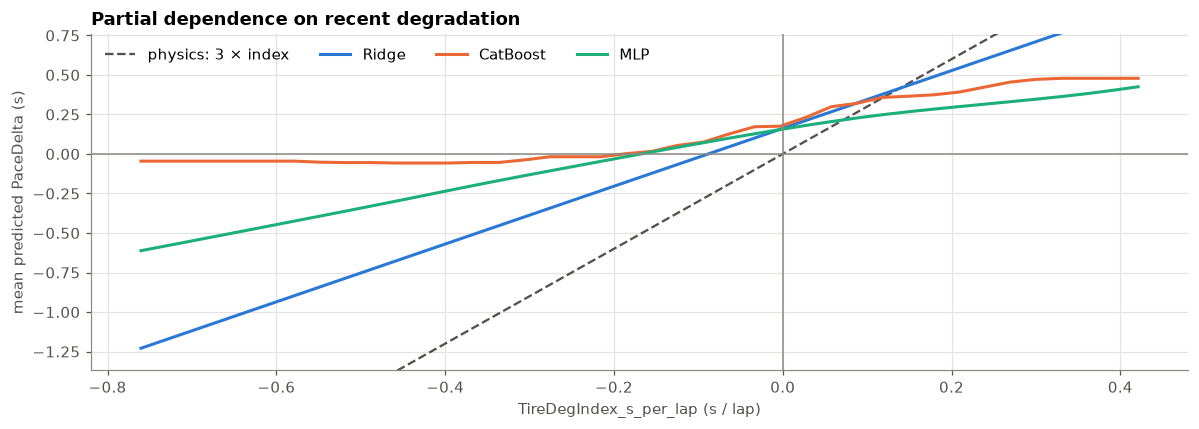

In [8]:
X_test, y_test = feature_matrix(split.test)
sample = X_test.sample(min(2000, len(X_test)), random_state=0)
grid = np.linspace(*X_test["TireDegIndex_s_per_lap"].quantile([0.02, 0.98]), 40)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(grid, 3 * grid, color=INK, linestyle="--", linewidth=1.5, label="physics: 3 × index")
for m in ["Ridge", "CatBoost", "MLP"]:
    curve = [result.models[m].predict(sample.assign(TireDegIndex_s_per_lap=v)).mean() for v in grid]
    ax.plot(grid, curve, color=MODEL_COLORS[m], label=m)
ax.axhline(0, color=NEUTRAL, linewidth=1); ax.axvline(0, color=NEUTRAL, linewidth=1)
ax.set_ylim(3 * grid[0] * 0.6, 3 * grid[-1] * 0.6)
ax.set_xlabel("TireDegIndex_s_per_lap (s / lap)"); ax.set_ylabel("mean predicted PaceDelta (s)")
ax.legend(ncol=4, loc="upper left")
ax.set_title("Partial dependence on recent degradation", loc="left")
plt.tight_layout()

## 3 Training dynamics and early stopping

Both advanced models stop when the **validation races** stop improving and keep the best state.

**What to look for**
* Training loss keeps falling; validation loss bottoms out and then flattens or rises.
* The vertical line (kept model) sits at the validation minimum.
* Here the validation curve is almost **flat** and far above training: the validation races
  (Netherlands, Italy, Singapore) are noisier than the training races, and beyond the first
  few trees / epochs there is little extra signal to learn - the models quickly start fitting
  noise of the training races, so early stopping ends training early.

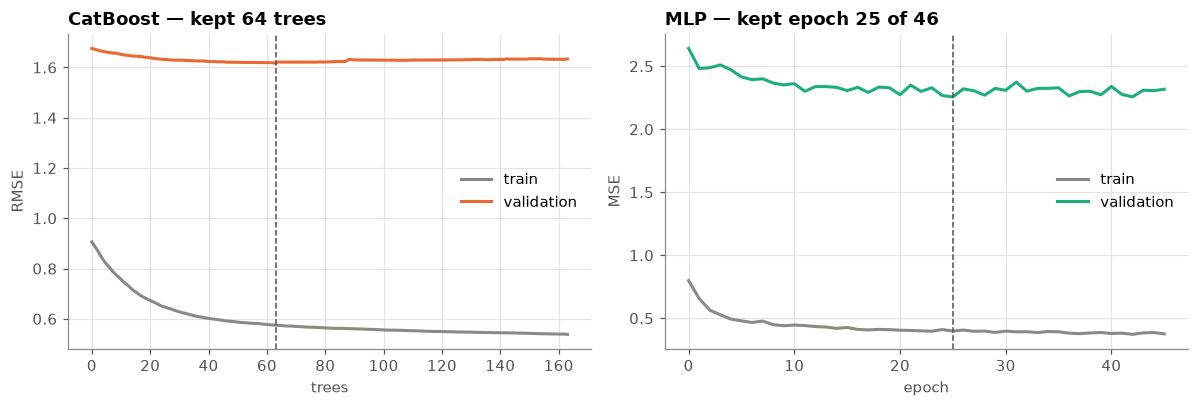

In [9]:
evals = cat.get_evals_result()
metric = next(iter(evals["learn"]))
hist = result.models["MLP"].history_

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(evals["learn"][metric], color=NEUTRAL, label="train")
ax.plot(evals["validation"][metric], color=MODEL_COLORS["CatBoost"], label="validation")
ax.axvline(cat.get_best_iteration(), color=INK, linestyle="--", linewidth=1)
ax.set_xlabel("trees"); ax.set_ylabel(metric)
ax.set_title(f"CatBoost — kept {cat.tree_count_} trees", loc="left"); ax.legend()
ax = axes[1]
ax.plot(hist.train_loss, color=NEUTRAL, label="train")
ax.plot(hist.val_loss, color=MODEL_COLORS["MLP"], label="validation")
ax.axvline(hist.best_epoch, color=INK, linestyle="--", linewidth=1)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_title(f"MLP — kept epoch {hist.best_epoch} of {len(hist.val_loss)}", loc="left"); ax.legend()
plt.tight_layout()

## 4 Conformal prediction intervals

**What to look for**
* Coverage close to 95 % for every model - the guarantee holds for **any** model, even Naive.
* The **width** is where models differ: a more accurate model earns a narrower interval.

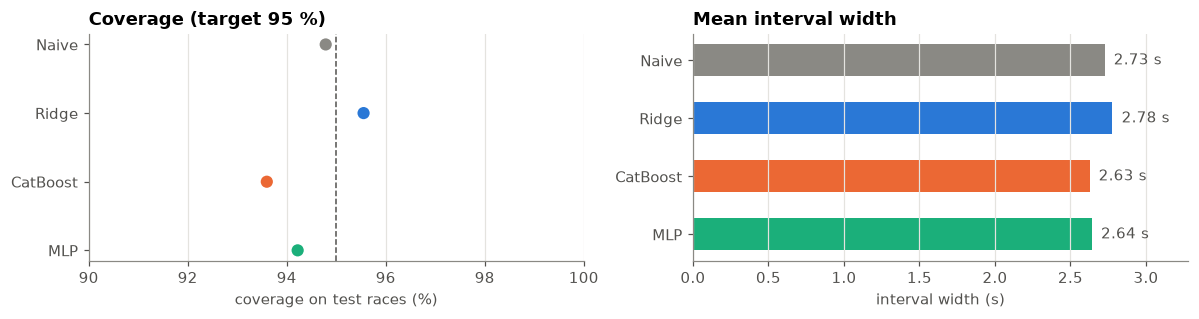

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
cov = metrics.loc[MODELS, "coverage"] * 100
axes[0].scatter(cov, MODELS, s=90, color=[MODEL_COLORS[m] for m in MODELS], edgecolor="white", linewidth=1.5, zorder=3)
axes[0].axvline(CONFIDENCE * 100, color=INK, linestyle="--", linewidth=1)
axes[0].set_xlim(90, 100); axes[0].set_xlabel("coverage on test races (%)")
axes[0].set_title("Coverage (target 95 %)", loc="left")
width = metrics.loc[MODELS, "mean_width"]
axes[1].barh(MODELS, width, color=[MODEL_COLORS[m] for m in MODELS], height=0.55)
for i, v in enumerate(width):
    axes[1].annotate(f"{v:.2f} s", (v, i), xytext=(6, 0), textcoords="offset points", va="center", color=INK, fontsize=10)
axes[1].set_xlim(0, width.max() * 1.18); axes[1].set_xlabel("interval width (s)")
axes[1].set_title("Mean interval width", loc="left")
for ax in axes:
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
plt.tight_layout()

### 4a Coverage per test race - where exchangeability breaks

The guarantee is about the **average** over laps that look like the calibration laps
(Japan, Qatar, USA). A race that is systematically different can fall below 95 %.

**What to look for**
* Most races at or above the line; any race clearly below it is a distribution shift, not a
  bug. Las Vegas 2023 was a brand-new street circuit, run at night on a track below 20 °C,
  far colder than anything the models trained or calibrated on.

model,Naive,Ridge,CatBoost,MLP
RaceId,,,,
2023_mexico_city,96.5,96.8,96.9,96.7
2023_sao_paulo,98.3,98.2,97.9,96.2
2023_las_vegas,82.0,85.1,73.6,80.1
2023_abu_dhabi,97.5,98.1,98.2,98.3


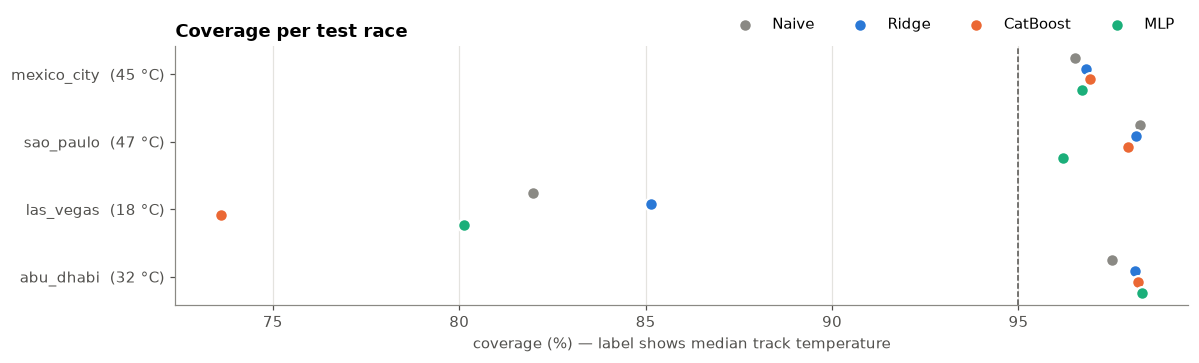

In [11]:
preds["inside"] = (preds["y_true"] >= preds["lower"]) & (preds["y_true"] <= preds["upper"])
cov_race = preds.pivot_table(index="RaceId", columns="model", values="inside", aggfunc="mean").loc[race_order, MODELS] * 100
track_temp = split.test.groupby("RaceId")["TrackTemp"].median().loc[race_order]

fig, ax = plt.subplots(figsize=(11, 3.4))
for off, m in zip(offsets, MODELS):
    ax.scatter(cov_race[m], np.arange(len(labels)) + off, s=70, color=MODEL_COLORS[m],
               edgecolor="white", linewidth=1.5, label=m, zorder=3)
ax.axvline(CONFIDENCE * 100, color=INK, linestyle="--", linewidth=1)
ax.set_yticks(range(len(labels)), [f"{l}  ({t:.0f} °C)" for l, t in zip(labels, track_temp)])
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("coverage (%) — label shows median track temperature")
ax.legend(ncol=4, loc="lower right", bbox_to_anchor=(1, 1.0))
ax.set_title("Coverage per test race", loc="left")
plt.tight_layout()
cov_race.round(1)

### 4b Marginal, not conditional, coverage
Split conformal uses **one** width `q` for every lap. So it over-covers easy laps and
under-covers hard ones - the 95 % holds on average, not for every kind of lap.

**What to look for**
* Coverage varying by compound / tyre age around the overall 95 %. Fixing that needs
  adaptive intervals.

In [12]:
best = metrics.drop(index="Naive")["MAE"].idxmin()
b = preds[preds["model"] == best]
by_compound = b.groupby(b["Compound"].astype(str))["inside"].agg(coverage="mean", laps="size")
by_age = b.groupby(pd.cut(b["TyreLife"], [0, 5, 10, 20, 80], labels=["1–5", "6–10", "11–20", "21+"]),
                   observed=True)["inside"].agg(coverage="mean", laps="size")
print(f"Model: {best}")
display(by_compound.style.format({"coverage": "{:.1%}"}), by_age.style.format({"coverage": "{:.1%}"}))

Model: Ridge


,coverage,laps
Compound,,
HARD,94.1%,1668
MEDIUM,96.8%,1252
SOFT,97.0%,610


,coverage,laps
TyreLife,,
1–5,91.9%,359
6–10,92.6%,840
11–20,97.1%,1468
21+,97.2%,863


### 4c One stint, back in lap-time space
Dots: actual fuel-corrected lap times. Grey dashed: the Naive forecast (`RollingPace_s`).
Coloured line and band: the best model's forecast `RollingPace_s + predicted delta` with its
95 % interval.

**What to look for**
* The band contains almost every dot; dots outside it are the "surprise" laps (traffic, a
  mistake, a push lap).
* The model line usually sits slightly **above** the Naive line: it expects the tyres to keep
  degrading.

98% of this stint's laps inside the interval


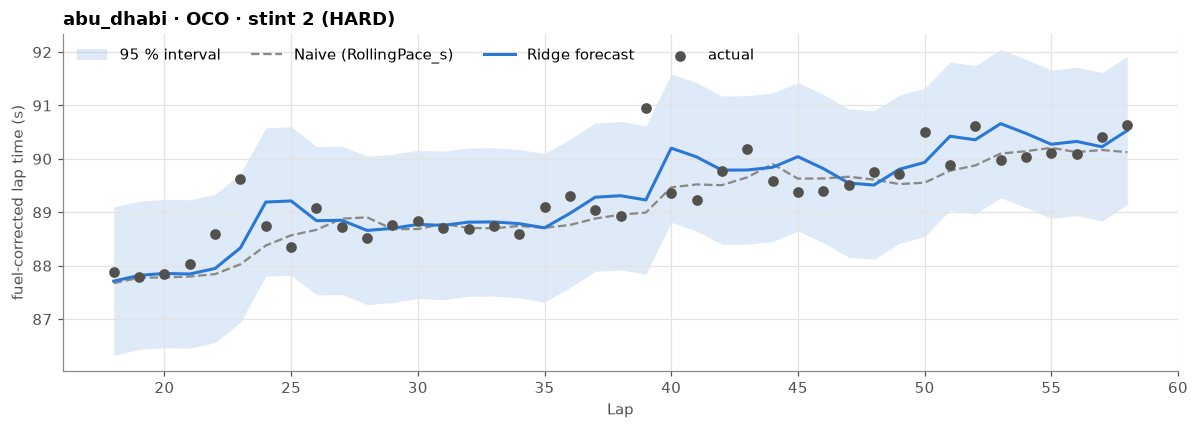

In [13]:
test_rows = split.test.reset_index(drop=True)
bp = b.reset_index(drop=True)  # predictions keep split.test's row order
stint_len = test_rows.groupby(["RaceId", "Driver", "Stint"], observed=True).size()
race_id, driver, stint = stint_len.drop(index="2023_las_vegas", level=0).idxmax()
mask = (test_rows["RaceId"] == race_id) & (test_rows["Driver"] == driver) & (test_rows["Stint"] == stint)
s, p = test_rows[mask], bp[mask]

fig, ax = plt.subplots(figsize=(11, 4))
forecast = s["RollingPace_s"] + p["y_pred"]
ax.fill_between(s["LapNumber"], s["RollingPace_s"] + p["lower"], s["RollingPace_s"] + p["upper"],
                color=MODEL_COLORS[best], alpha=0.15, linewidth=0, label="95 % interval")
ax.plot(s["LapNumber"], s["RollingPace_s"], color=NEUTRAL, linestyle="--", linewidth=1.5, label="Naive (RollingPace_s)")
ax.plot(s["LapNumber"], forecast, color=MODEL_COLORS[best], label=f"{best} forecast")
ax.scatter(s["LapNumber"], s["FuelCorrectedLapTime_s"], s=36, color=INK, zorder=3, label="actual")
ax.set_xlabel("Lap"); ax.set_ylabel("fuel-corrected lap time (s)"); ax.legend(ncol=4, loc="upper left")
ax.set_title(f"{race_id.removeprefix('2023_')} · {driver} · stint {int(stint)} ({s['Compound'].astype(str).iloc[0]})", loc="left")
plt.tight_layout()
inside = ((s["FuelCorrectedLapTime_s"] >= s["RollingPace_s"] + p["lower"]) &
          (s["FuelCorrectedLapTime_s"] <= s["RollingPace_s"] + p["upper"])).mean()
print(f"{inside:.0%} of this stint's laps inside the interval")

## 5 Cross-check: hand-written conformal vs MAPIE

`split_conformal_quantile` + `conformal_interval` against MAPIE's `SplitConformalRegressor`,
for every fitted model.

**What to look for**
* A maximum difference of 0 (floating-point noise at most) for every model.

In [14]:
X_calib, y_calib = feature_matrix(split.calib)
rows = []
for name, model in result.models.items():
    q = split_conformal_quantile(y_calib - model.predict(X_calib), CONFIDENCE)
    lower, upper = conformal_interval(model.predict(X_test), q)
    _, m_lower, m_upper = mapie_split_conformal(model, X_calib, y_calib, X_test, CONFIDENCE)
    rows.append({"model": name, "q": q, "max |lower diff|": np.abs(lower - m_lower).max(),
                 "max |upper diff|": np.abs(upper - m_upper).max()})
check = pd.DataFrame(rows).set_index("model")
assert (check.filter(like="diff") < 1e-9).all().all(), "hand-written conformal disagrees with MAPIE"
check

,q,max |lower diff|,max |upper diff|
model,,,
Naive,1.363000,0.0,0.0
Ridge,1.389106,0.0,0.0
CatBoost,1.313074,0.0,0.0
MLP,1.320874,0.0,0.0


## 6 Experiment: a loss function that ignores the tails

CatBoost was trained with **RMSE**, which squares errors: one 5 s traffic lap counts as much as
25 laps that are 1 s off, so the trees bend towards the outliers. **Huber** loss is squared for
small errors and linear for large ones (here beyond 1 s), so outliers pull less.

**What to look for**
* Lower MAE with Huber (it fits the typical lap, which is what MAE measures).
* Possibly a slightly higher RMSE (it gives up on the tails) and a narrower interval.

In [15]:
X_train, y_train = feature_matrix(split.train)
X_val, y_val = feature_matrix(split.val)

def evaluate(model):
    pred = model.predict(X_test)
    q = split_conformal_quantile(y_calib - model.predict(X_calib), CONFIDENCE)
    lower, upper = conformal_interval(pred, q)
    return {"MAE": np.abs(y_test - pred).mean(), "RMSE": np.sqrt(((y_test - pred) ** 2).mean()),
            "trees": model.tree_count_, **interval_metrics(y_test, lower, upper)}

huber = fit_catboost(make_catboost(loss_function="Huber:delta=1.0"), X_train, y_train, X_val, y_val)
loss_cmp = pd.DataFrame({"CatBoost · RMSE loss": evaluate(cat), "CatBoost · Huber loss": evaluate(huber)}).T
loss_cmp["MAE_vs_naive"] = 1 - loss_cmp["MAE"] / metrics.loc["Naive", "MAE"]
loss_cmp.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "trees": "{:.0f}", "coverage": "{:.1%}",
                       "mean_width": "{:.3f}", "MAE_vs_naive": "{:+.1%}"})

,MAE,RMSE,trees,coverage,mean_width,MAE_vs_naive
CatBoost · RMSE loss,0.441,0.658,64,93.6%,2.626,+3.2%
CatBoost · Huber loss,0.418,0.631,108,94.4%,2.638,+8.3%


## 7 Takeaways

In [16]:
print(f"Best benchmark model by MAE      : {best} ({metrics.loc[best, 'MAE_vs_naive']:+.1%} vs Naive)")
print(f"CatBoost with Huber loss         : {loss_cmp.loc['CatBoost · Huber loss', 'MAE_vs_naive']:+.1%} vs Naive")
print(f"MLP vs Naive                     : {metrics.loc['MLP', 'MAE_vs_naive']:+.1%}")
print(f"Coverage range across models     : {metrics['coverage'].min():.1%} – {metrics['coverage'].max():.1%}")
worst = cov_race.min(axis=1).idxmin()
print(f"Worst test race for coverage     : {worst.removeprefix('2023_')} ({cov_race.loc[worst].min():.1f} – {cov_race.loc[worst].max():.1f} %)")

Best benchmark model by MAE      : Ridge (+3.8% vs Naive)
CatBoost with Huber loss         : +8.3% vs Naive
MLP vs Naive                     : -4.0%
Coverage range across models     : 93.6% – 95.6%
Worst test race for coverage     : las_vegas (73.6 – 85.1 %)


1. **Recent form is a strong baseline.** After the Phase 2 clean-up, the best models improve
   on "same as recent form" by only a few percent (up to ~8 % with Huber CatBoost). Most of the
   remaining lap-to-lap variation is traffic, DRS and driver behaviour - information that is not
   in our features. That is a finding, not a failure: the benchmark tells us what to add next
   (gap to the car ahead, DRS, fuel-saving / lift-and-coast phases).
2. **More model capacity did not help.** The MLP is below Naive and CatBoost stops after a few
   dozen trees: with ~13 k training laps and weak features, flexibility mostly fits noise.
   The linear model with good regularisation is the hardest to beat - a common result on small
   tabular data.
3. **The loss function matters more than the model family here.** Switching CatBoost from RMSE
   to Huber gave the biggest single gain, because the target is heavy-tailed.
4. **Conformal intervals keep their promise on average** (~94–96 % coverage, for every model,
   with no distributional assumptions) **but only for laps that resemble the calibration laps.**
   Las Vegas - new, cold, unlike anything in calibration - drops to ~74–85 %. Coverage per
   race is the honest way to report intervals for a time-ordered problem.